# Task 1

In [63]:
area = [2600,3000, 3200, 3600, 4000, 4100]

In [64]:
price = [550000,565000,610000,595000,760000,810000]

In [65]:
x = area

In [66]:
y = price

In [67]:
print(x)

[2600, 3000, 3200, 3600, 4000, 4100]


In [68]:
print(y)

[550000, 565000, 610000, 595000, 760000, 810000]


In [69]:
w=200

In [70]:
b=50000

In [71]:
b = -40000
w=200

In [ ]:
epochs = 200000
# w = price[0]/area[0]
# w = 188.9270799949798  
# w = 77666.40818883755  

# b= 0.0
# b = 1000
# b = 999.9955472851933
# b = 570970.143262745
alpha = 0.00000001
jwb = 0
m = len(x) # number of training examples
for i in range(epochs):
    total_wxbyx = 0 # total(wx+b-y)x
    total_wxby = 0 # total(wx+b-y)
    squared_total_wxby = 0
    for j in range(len(x)):
        Xi = x[j]
        Yi = y[j]
        #fwb = w * Xi + b
        total_wxbyx += (w * Xi + b - Yi) * Xi
        total_wxby += (w * Xi + b - Yi)
        squared_total_wxby += (w * Xi + b - Yi) ** 2
    jwb = (1 / (2 * m)) * squared_total_wxby

    print("Epoch: ",i+1," Cost: ",jwb," w: ",w," b: ",b)
    
    temp_w = w - alpha * (1 / m) * total_wxbyx
    temp_b = b - alpha * (1 / m) * total_wxby

    w = temp_w
    b = temp_b

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
x = np.array(x)

In [ ]:
u = w * x + b

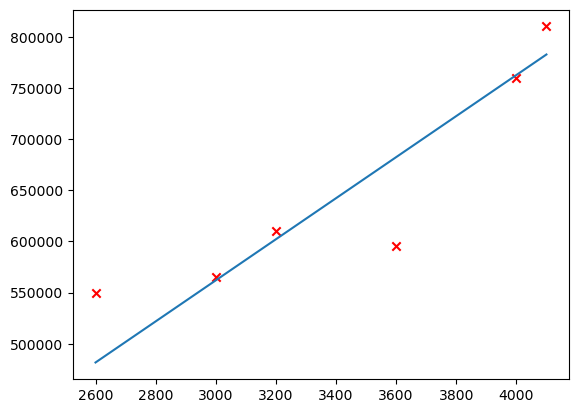

In [ ]:
plt.scatter(x,y,marker='x',c='r')
plt.plot(x, u)

In [ ]:
# predict 1500 
print("Predicted value for 1500: ", w * 1500 + b)

Predicted value for 1500:  260964.61686741392


# Task 2

In [172]:
%%file student_perfromance.csv
student_id,name,study_hours,attendance,assignment_score,exam_score
STU001,Ali,3,75,68,65
STU002,Sara,5,90,85,88
STU003,John,2,70,60,58
STU004,Ayesha,6,95,92,94
STU005,Bilal,4,80,75,73
STU006,Hina,7,98,90,96
STU007,Omar,1,65,55,50
STU008,Maryam,5,88,82,84


Overwriting student_perfromance.csv


In [1]:
import pandas
import matplotlib.pyplot as plt
import numpy as np
import time
from IPython.display import clear_output



In [102]:
cost_history = []

In [103]:
df = pandas.read_csv("student_perfromance.csv")

In [104]:
df[['x','y']] = df[["attendance","exam_score"]]

In [105]:
df = df[['x','y']] 

In [106]:
df

,x,y
0,75,65
1,90,88
2,70,58
3,95,94
4,80,73
5,98,96
6,65,50
7,88,84


In [107]:
x=df['x']

In [108]:
x=list(x)

In [109]:
print(x)

[75, 90, 70, 95, 80, 98, 65, 88]


In [110]:
y=df['y']

In [111]:
y=list(y)

In [112]:
print(y)

[65, 88, 58, 94, 73, 96, 50, 84]


In [113]:
w=1.3742445144817537      
b=-37.46278290083005

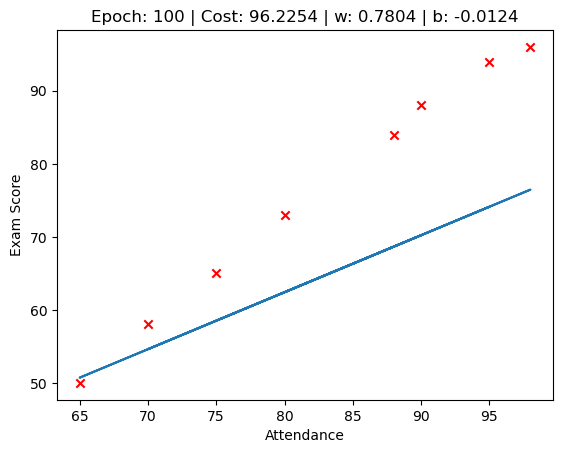

In [ ]:
epochs = 100
w = 0
b = 0
alpha = 0.0001 #0.000285
jwb = 0
m = len(x) # number of training examples
for i in range(epochs):
    total_wxbyx = 0 # total(wx+b-y)x
    total_wxby = 0 # total(wx+b-y)
    squared_total_wxby = 0
    for j in range(len(x)):
        Xi = x[j]
        Yi = y[j]
        #fwb = w * Xi + b
        total_wxbyx += (w * Xi + b - Yi) * Xi
        total_wxby += (w * Xi + b - Yi)
        squared_total_wxby += (w * Xi + b - Yi)**2
    jwb = (1 / (2 * m)) * squared_total_wxby
    cost_history.append(jwb)#

    print("Epoch: ",i+1," Cost: ",jwb," w: ",w," b: ",b)
    
    temp_w = w - alpha * (1 / m) * total_wxbyx
    temp_b = b - alpha * (1 / m) * total_wxby

    w = temp_w
    b = temp_b

# Live visualization#
clear_output(wait=True)#

plt.scatter(x, y, marker='x', c='r')#

x_line = np.array(x)#
y_line = w * x_line + b#

plt.plot(x_line, y_line)#

plt.xlabel("Attendance")#
plt.ylabel("Exam Score")#
plt.title(f"Epoch: {i+1} | Cost: {jwb:.4f} | w: {w:.4f} | b: {b:.4f}")#

plt.show()#

time.sleep(0.2)#

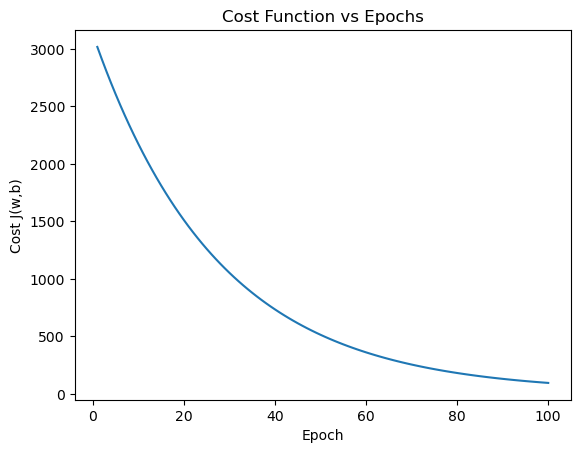

In [115]:
plt.plot(range(1, epochs + 1), cost_history)

plt.xlabel("Epoch")
plt.ylabel("Cost J(w,b)")
plt.title("Cost Function vs Epochs")

plt.show()

# TASK 3

In [116]:
%%file houses.csv
area,bedrooms,bathrooms,price
800,2,1,4.0
1000,3,1,4.8
1200,2,2,5.3
1400,3,2,6.2
1600,4,2,7.1
1800,3,3,7.6
2000,4,3,8.6
2200,5,3,9.4

Writing houses.csv


In [121]:
import pandas as pd
import numpy as np

df = pd.read_csv("houses.csv")

X = df[['area','bedrooms','bathrooms']].values
y = df['price'].values

mean = X.mean(axis=0)
r = X.max(axis=0) - X.min(axis=0)

X = (X - mean) / r

In [122]:
def gradient_descent(X, y):
    X = np.c_[np.ones(len(X)), X]
    w = np.zeros(X.shape[1])
    alpha = 0.1

    for i in range(5000):
        error = X @ w - y
        w = w - alpha * (X.T @ error) / len(y)

    return w

In [123]:
w_multi = gradient_descent(X, y)
print(w_multi)

[6.625 1.82  1.9   1.76 ]


In [124]:
w_single = gradient_descent(X[:,[0]], y)

pred_single = np.c_[np.ones(len(X)), X[:,[0]]] @ w_single
pred_multi = np.c_[np.ones(len(X)), X] @ w_multi

mse_single = np.mean((y-pred_single)**2)
mse_multi = np.mean((y-pred_multi)**2)

print("Single MSE:", mse_single)
print("Multiple MSE:", mse_multi)

Single MSE: 0.011845238095238093
Multiple MSE: 0.001833333333333323


In [125]:
house = np.array([1800,3,2])

house = (house - mean) / r

price = np.r_[1,house] @ w_multi

print("Predicted Price:", price, "million PKR")

Predicted Price: 6.746666666667715 million PKR
